# Predict logP

The aim of this exercise is to compare model performance between a GNN and a supervised method to predict logP. 
Consider as a starting point one of the GNNs from session 14 (GCN, GIN, or GAT), and a supervised model of your choice (e.g., Random Forest with MACCS fingerprints).

#### Tasks:
1) Create a training and a test set
2) Build a supervised model of your choice on the training data and evaluate its performance on the test set
3) Build a GNN and compare its performance to the supervised model
4) Discuss the outcome


In [79]:
# complete imports if needed for your solution
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from rdkit.Chem import RDKFingerprint
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import torch
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch_geometric.nn import GCNConv, GINConv, GATConv
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch_geometric.data import Data

Load the data from Session 11

In [80]:
df = pd.read_csv("esol_modified.csv").dropna(subset=["SMILES"])
df = df.loc[df.SMILES != 'C'] # remove the one compound containing only a single atom
df.head()

,SMILES,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,0.000000,202.32,12.0,1.0,32.0,3.0,0.217518,7.0,12.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,6.263163,42.24,2.0,2.0,15.0,2.0,0.811283,1.0,3.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,5.573105,17.07,1.0,0.0,11.0,0.0,0.343706,0.0,1.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,43.089794,0.00,0.0,5.0,22.0,5.0,0.291526,0.0,0.0
4,c1ccsc1,-1.33,84.143,1.74810,0.000000,0.00,1.0,1.0,5.0,1.0,0.448927,0.0,0.0


### Setting the stage
Split the data into training and test sets. The test set will be used to compare model performance.

In [81]:
X1 = df.drop(columns=["LogP"])
y1 = df["LogP"]

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

### Baseline supervised model
Choose a 
   - regression model (RF, SVR, kNN, Gradient Boost, ...) 
   - molecular descriptor (RDKit, Mordred, ...) or fingerprint (MACCS, Morgan, RDKit, ...)
      
Build a feature matrix and target vector. Add scaling if needed for your model.
Train the model on the training set and apply it to the test set.
Calculate performance metrics (R2, RMSE) for model performance on the test set.

In [82]:
# Using MorganFP with RF
def smiles_to_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return mol

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def morganfp(mol):
    if mol is None:
        return None
    fp = morgan_gen.GetFingerprint(mol)
    return np.array(fp)

df["mol"] = df["SMILES"].apply(smiles_to_mol)
df["MorganFP"] = df["mol"].apply(morganfp)

df = df.dropna(subset=["MorganFP"]).copy()

In [83]:
X = pd.DataFrame(df["MorganFP"].tolist())
y = df["LogP"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)


R2: 0.7662569477271985
MSE: 0.8454280701334919
RMSE: 0.9194716255184234


### Unpervised GNN model
Choose a GNN architecture
   - GCN, GIN, or GAT
      
Transform input smiles to graph objects using the atom and bond features. Build graphs for both training and test set. Train the GNN on the training set. Adapt architecture and parameters until you are happy with the performance. Apply the trained model on the test set (once!) and calculate model performance metrics

Using code from lecture 14

In [84]:
import torch.nn.functional as F
class GCNModel(torch.nn.Module):
    def __init__(self, dim_h=128, dropout = 0.2): # dim_h: Size of hidden layer
        super().__init__()
        self.conv1 = GCNConv(5, dim_h) # first convolution layer: in_channels: 5, number of atom features
        self.conv2 = GCNConv(dim_h, dim_h) # second convolution layer
        self.conv3 = GCNConv(dim_h, dim_h)
        self.lin = torch.nn.Linear(dim_h, 1) # output layer
        self.dropout = dropout
    # Define how the data flows through the layers
    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))  # input layer: convolution + activation function (ReLu)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = torch.relu(self.conv2(x, edge_index))  # hidden layer: convolution + activation function (ReLu)
        x = global_mean_pool(x, batch)             # pooling function
        return self.lin(x).squeeze(-1)


In [85]:
# Transforming input smiles to graph objects

def atom_features(atom): # Create a tensor for atom features, length = 5
    return torch.tensor([
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ], dtype=torch.float)

def bond_features(bond): # Create a tensor for bond features, length = 6
    bt = bond.GetBondType()
    return torch.tensor([
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing(),
    ], dtype=torch.float)

def smiles_to_graph(smiles, y):
    mol = Chem.MolFromSmiles(smiles) # Create a RDKit mol object from the smiles

    # Calculate atom features for all atoms in the molecule
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)

    # Edges
    edge_index = []
    edge_attr = []
    
    # Iterate through all bonds in the molecule
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Represent molecule as an undirected graph --> add both directions
        edge_index.append([i, j]) # left to right
        edge_index.append([j, i]) # right to left

        bf = bond_features(bond) # calculate bond features 
        edge_attr.append(bf)
        edge_attr.append(bf) # add two times, once for forward and once for backwards edge

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous() 
    edge_attr  = torch.stack(edge_attr, dim=0)

    # Target property: logP
    y = torch.tensor([y], dtype=torch.float)
    
    # x: atom stack, y: logP
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [86]:
# Obtaining graph representation from smiles
graphs = [smiles_to_graph(row.SMILES, row.LogP) for _, row in df.iterrows()]

In [87]:
def train(model, train_loader, val_loader, epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # lr: learning rate
    criterion = torch.nn.MSELoss() # loss function

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad() # Reset gradients
            pred = model(batch.x, batch.edge_index, batch.batch) # predict on batch
            loss = criterion(pred, batch.y) # define criterion
            loss.backward() # computes the gradient of the loss
            optimizer.step() # Perform an optimization step
            train_losses.append(loss.item())

        val_loss = evaluate(model, val_loader) # evaluate re-trained model on validation data

        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss = {sum(train_losses)/len(train_losses):.4f} | " # average train loss
              f"Val Loss = {val_loss:.4f}") 


def test(model, test_loader):
    test_loss = evaluate(model, test_loader)
    print(f"\nTest Loss: {test_loss:.4f}")


In [88]:
def create_splits(graphs, train_ratio=0.8, val_ratio=0.1, seed=42):
    torch.manual_seed(seed)
    graphs = graphs.copy()
    permutation = torch.randperm(len(graphs))
    graphs = [graphs[i] for i in permutation]

    n = len(graphs)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_graphs = graphs[:n_train]
    val_graphs   = graphs[n_train:n_train + n_val]
    test_graphs  = graphs[n_train + n_val:]

    return train_graphs, val_graphs, test_graphs

train_graphs, val_graphs, test_graphs = create_splits(graphs)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=32)
test_loader  = DataLoader(test_graphs, batch_size=32)

In [89]:
def evaluate(model, loader):
    model.eval()
    criterion = torch.nn.MSELoss()
    losses = []

    with torch.no_grad():
        for batch in loader:
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(pred, batch.y)
            losses.append(loss.item())

    return sum(losses) / len(losses)

In [90]:
loader = DataLoader(graphs, batch_size=100, shuffle=True)

gcn = GCNModel()

epochs = 100

print("\n=== Training GCN ===")
train(gcn, train_loader, val_loader, epochs=epochs)


=== Training GCN ===
Epoch 01 | Train Loss = 4.5491 | Val Loss = 5.2805
Epoch 02 | Train Loss = 3.5527 | Val Loss = 5.1984
Epoch 03 | Train Loss = 3.3480 | Val Loss = 5.1182
Epoch 04 | Train Loss = 3.3037 | Val Loss = 5.0683
Epoch 05 | Train Loss = 3.3379 | Val Loss = 4.9872
Epoch 06 | Train Loss = 3.1739 | Val Loss = 4.9430
Epoch 07 | Train Loss = 3.2496 | Val Loss = 4.7048
Epoch 08 | Train Loss = 2.9948 | Val Loss = 4.5668
Epoch 09 | Train Loss = 2.9703 | Val Loss = 4.5471
Epoch 10 | Train Loss = 2.8922 | Val Loss = 4.4407
Epoch 11 | Train Loss = 2.8915 | Val Loss = 4.4508
Epoch 12 | Train Loss = 2.8515 | Val Loss = 4.2783
Epoch 13 | Train Loss = 2.7828 | Val Loss = 4.1026
Epoch 14 | Train Loss = 2.7563 | Val Loss = 4.0020
Epoch 15 | Train Loss = 2.7877 | Val Loss = 4.5936
Epoch 16 | Train Loss = 2.7449 | Val Loss = 3.8924
Epoch 17 | Train Loss = 2.6849 | Val Loss = 3.7536
Epoch 18 | Train Loss = 2.5300 | Val Loss = 3.6681
Epoch 19 | Train Loss = 2.4671 | Val Loss = 3.8726
Epoch 20 

## Using test once


Test Loss: 1.2508
Test MSE:  1.0932
Test RMSE: 1.0455
Test R2:   0.4864


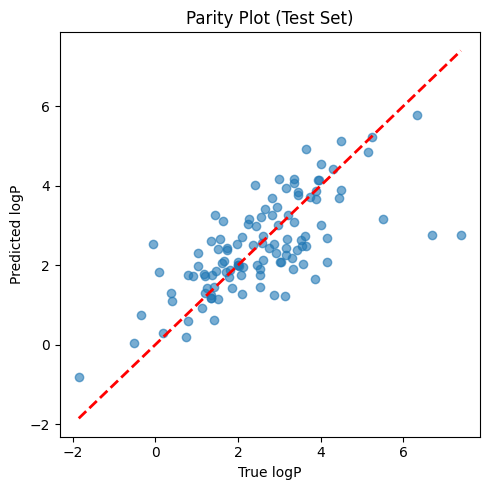

In [91]:
# Visualization

test(gcn, test_loader)

import matplotlib.pyplot as plt
def parity_plot(model, test_loader, title="Parity Plot (Test Set)"):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for batch in test_loader:
            pred = model(batch.x, batch.edge_index, batch.batch)

            # Ensure correct shapes
            pred = pred.view(-1).cpu()
            y = batch.y.view(-1).cpu()

            preds.append(pred)
            trues.append(y)

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    mse = mean_squared_error(trues, preds)
    rmse = mse ** 0.5
    r2 = r2_score(trues, preds)

    print(f"Test MSE:  {mse:.4f}")
    print(f"Test RMSE: {rmse:.4f}")
    print(f"Test R2:   {r2:.4f}")
    
    # Parity plot
    plt.figure(figsize=(5,5))
    plt.scatter(trues, preds, alpha=0.6)
    plt.plot([trues.min(), trues.max()],
             [trues.min(), trues.max()],
             color='red', linestyle='--', linewidth=2)

    plt.xlabel("True logP")
    plt.ylabel("Predicted logP")
    plt.title(title)
    plt.tight_layout()
    plt.show()

parity_plot(gcn, test_loader)

### Discussion points
1) Which model (supervised or unsupervised) performed better on the test set, and why?
2) What did you try to improve model performance of your GNN? What did work, what did not work?
3) Which challenges did you face in the process of building the models?
4) Which of your two models would you recommend to a chemist for predicting logP, and why?

1. The supervised model performed better on the test set, RF outperformed GNN in this case, it had a higher R2 and a lower RMSE. As for why, im not entirely sure but supervised models are better for prediction and the random forest could get patetrns in the smiles better.
2. First thing I did was change the dim_h. The highest I went is 128 which also worked the best. Lowering to 64 and 32 made the model even worse. Then I added a dropout which improved the model slightly. Added a third hidden layer which also improved it slightly. I of course also played a bit with the epochs, what I found with the paramters I had was that the sweet spot wwas 100-150 epochs. Lowering it made it worse, the same goes for increasing it. It kinda stayed consistent from 100-150 so in the end I stuck with 100.
3. When taking the code from lecture 14, I first struggeled a bit with what is test and what is training. But I think I figured it out. Also im kinda surprised in the performance, maybe I did something wrong but I didnt expect it too be this bad what makes me beleiev I did something wrong.
4. I would go for random forest not only because it gave me better results but also because it is way easier to set up.